# Spam Detection - Exploratory Data Analysis

## 1. Introduction

This notebook performs exploratory data analysis on the SMS spam
dataset. The goal is to understand the characteristics of spam vs ham
messages to inform our preprocessing and modeling decisions.

**Project Goal**: Build a binary classifier to identify spam messages
from SMS text data.

### Import Libraries

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import re

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Data

Load the spam dataset and perform initial inspection.

In [2]:
# Load dataset with latin-1 encoding to handle special characters
df = pd.read_csv(
    "../data/input/spam.csv",
    encoding="latin-1",
)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (5572, 5)

Column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Display data types
print("Data types:")
print(df.dtypes)
print(f"\nDataset info:")
df.info()

Data types:
v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [4]:
# Rename columns and drop empty ones
df = df.rename(columns={"v1": "label", "v2": "text"})
df = df[["label", "text"]]

print("After renaming and dropping empty columns:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

After renaming and dropping empty columns:
Shape: (5572, 2)
Columns: ['label', 'text']


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Data Quality Check

Examine the dataset for missing values, duplicates, and data quality
issues.

In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values:
label    0
text     0
dtype: int64

Total missing: 0


In [6]:
# Check for duplicates
duplicates = df.duplicated(subset=["text"])
print(f"Number of duplicate messages: {duplicates.sum()}")
print(
    f"Percentage of duplicates: "
    f"{duplicates.sum() / len(df) * 100:.2f}%"
)

if duplicates.sum() > 0:
    print(f"\nExample duplicates:")
    print(df[df.duplicated(subset=["text"], keep=False)].head(10))

Number of duplicate messages: 403
Percentage of duplicates: 7.23%

Example duplicates:
   label                                               text
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
7    ham  As per your request 'Melle Melle (Oru Minnamin...
8   spam  WINNER!! As a valued network customer you have...
9   spam  Had your mobile 11 months or more? U R entitle...
11  spam  SIX chances to win CASH! From 100 to 20,000 po...
12  spam  URGENT! You have won a 1 week FREE membership ...
45   ham                   No calls..messages..missed calls
62   ham                          Its a part of checking IQ
65  spam  As a valued customer, I am pleased to advise y...
66   ham  Today is \song dedicated day..\" Which song wi...


In [7]:
# Data cleaning summary
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate messages: {duplicates.sum()} "
      f"({duplicates.sum() / len(df) * 100:.2f}%)")
print(f"Unique labels: {df['label'].unique().tolist()}")
print("=" * 60)

DATA QUALITY SUMMARY
Total rows: 5,572
Total columns: 2
Missing values: 0
Duplicate messages: 403 (7.23%)
Unique labels: ['ham', 'spam']


## 4. Class Distribution Analysis

Analyze the balance between ham and spam messages. This is critical
for understanding model evaluation metrics.

In [8]:
# Count messages by class
class_counts = df["label"].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nPercentages:")
print(df["label"].value_counts(normalize=True) * 100)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


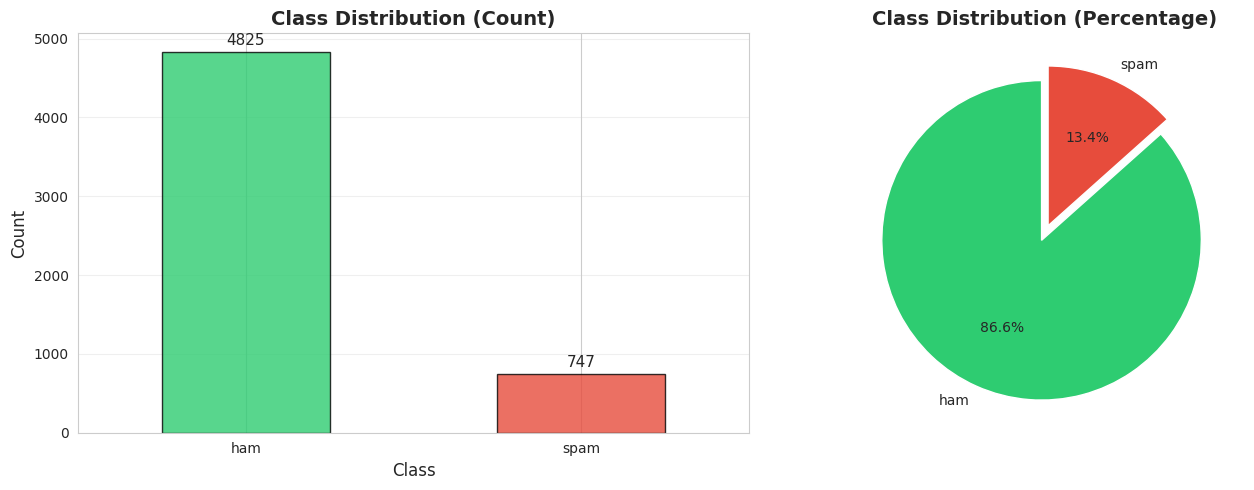

In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["#2ecc71", "#e74c3c"]  # Green for ham, red for spam
class_counts.plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    edgecolor="black",
    alpha=0.8,
)
axes[0].set_title("Class Distribution (Count)", fontsize=14, weight="bold")
axes[0].set_xlabel("Class", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# Add value labels on bars
for i, v in enumerate(class_counts):
    axes[0].text(
        i, v + 50, str(v), ha="center", va="bottom", fontsize=11
    )

# Pie chart
axes[1].pie(
    class_counts,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05),
)
axes[1].set_title(
    "Class Distribution (Percentage)", fontsize=14, weight="bold"
)

plt.tight_layout()
plt.show()

In [10]:
# Calculate class imbalance ratio
spam_count = class_counts["spam"]
ham_count = class_counts["ham"]
imbalance_ratio = ham_count / spam_count

print(f"\n{'=' * 60}")
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)
print(f"Ham messages: {ham_count:,} "
      f"({ham_count / len(df) * 100:.2f}%)")
print(f"Spam messages: {spam_count:,} "
      f"({spam_count / len(df) * 100:.2f}%)")
print(f"\nImbalance ratio (ham:spam): {imbalance_ratio:.2f}:1")
print("=" * 60)


CLASS IMBALANCE ANALYSIS
Ham messages: 4,825 (86.59%)
Spam messages: 747 (13.41%)

Imbalance ratio (ham:spam): 6.46:1


### Why Precision Matters for Spam Detection

**Class Imbalance**: The dataset is imbalanced with more ham than spam
messages.

**Metric Implications**:
- **Precision** (spam): Percentage of predicted spam that is actually
  spam. Critical because false positives (ham classified as spam) can
  cause users to miss important messages.
- **Recall** (spam): Percentage of actual spam correctly identified.
  Important for catching spam, but less critical than precision.
- **F1-Score**: Harmonic mean of precision and recall, provides
  balanced view.

**Recommendation**: Focus on maximizing precision while maintaining
acceptable recall. A false positive (blocking legitimate messages) is
worse than a false negative (letting spam through).

## 5. Text Length Analysis

Compare the length characteristics of spam vs ham messages.

In [11]:
# Calculate text length features
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Text length statistics:")
print(df[["label", "char_count", "word_count"]].groupby("label").describe())

Text length statistics:


      char_count                                                           \
           count        mean        std   min    25%    50%    75%    max   
label                                                                       
ham       4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0   
spam       747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0   

      word_count                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
ham       4825.0  14.200622  11.424511  1.0   7.0  11.0  19.0  171.0  
spam       747.0  23.851406   5.811898  2.0  22.0  25.0  28.0   35.0  


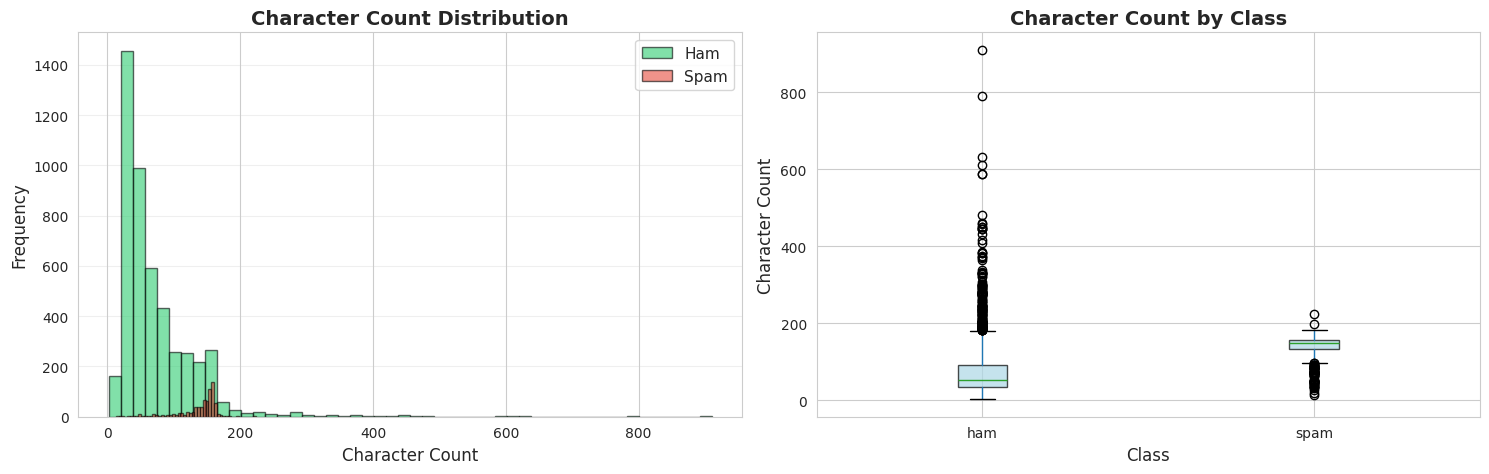

In [12]:
# Visualize character count distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
for label, color in zip(["ham", "spam"], ["#2ecc71", "#e74c3c"]):
    data = df[df["label"] == label]["char_count"]
    axes[0].hist(
        data,
        bins=50,
        alpha=0.6,
        label=label.capitalize(),
        color=color,
        edgecolor="black",
    )

axes[0].set_title(
    "Character Count Distribution", fontsize=14, weight="bold"
)
axes[0].set_xlabel("Character Count", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# Box plot
df.boxplot(
    column="char_count",
    by="label",
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", alpha=0.7),
)
axes[1].set_title(
    "Character Count by Class", fontsize=14, weight="bold"
)
axes[1].set_xlabel("Class", fontsize=12)
axes[1].set_ylabel("Character Count", fontsize=12)
plt.suptitle("")  # Remove default title

plt.tight_layout()
plt.show()

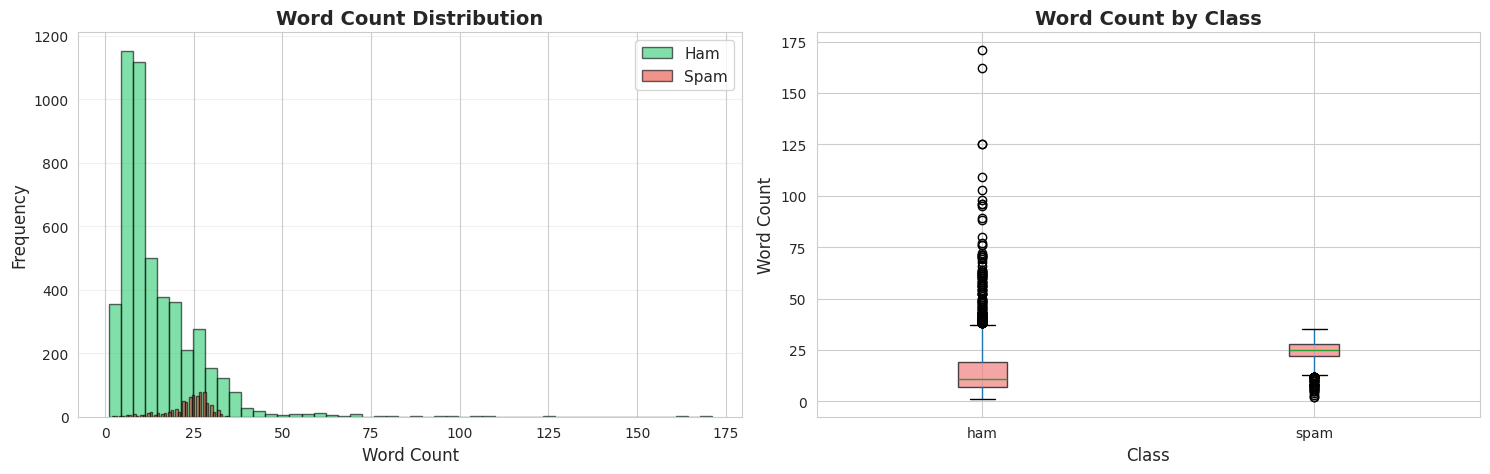

In [13]:
# Visualize word count distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
for label, color in zip(["ham", "spam"], ["#2ecc71", "#e74c3c"]):
    data = df[df["label"] == label]["word_count"]
    axes[0].hist(
        data,
        bins=50,
        alpha=0.6,
        label=label.capitalize(),
        color=color,
        edgecolor="black",
    )

axes[0].set_title("Word Count Distribution", fontsize=14, weight="bold")
axes[0].set_xlabel("Word Count", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# Box plot
df.boxplot(
    column="word_count",
    by="label",
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="lightcoral", alpha=0.7),
)
axes[1].set_title("Word Count by Class", fontsize=14, weight="bold")
axes[1].set_xlabel("Class", fontsize=12)
axes[1].set_ylabel("Word Count", fontsize=12)
plt.suptitle("")  # Remove default title

plt.tight_layout()
plt.show()

In [14]:
# Statistical comparison
print("\n" + "=" * 60)
print("TEXT LENGTH COMPARISON")
print("=" * 60)

for metric in ["char_count", "word_count"]:
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print("-" * 60)
    for label in ["ham", "spam"]:
        data = df[df["label"] == label][metric]
        print(f"{label.capitalize()}: "
              f"Mean={data.mean():.1f}, "
              f"Median={data.median():.1f}, "
              f"Std={data.std():.1f}")


TEXT LENGTH COMPARISON

CHAR COUNT:
------------------------------------------------------------
Ham: Mean=71.0, Median=52.0, Std=58.0
Spam: Mean=138.9, Median=149.0, Std=29.2

WORD COUNT:
------------------------------------------------------------
Ham: Mean=14.2, Median=11.0, Std=11.4
Spam: Mean=23.9, Median=25.0, Std=5.8


## 6. Word Frequency Analysis

Identify the most common words in the entire dataset, spam messages,
and ham messages.

In [15]:
def get_word_frequencies(texts, top_n=20):
    """Extract word frequencies from list of texts.

    Args:
        texts: List of text strings.
        top_n: Number of top words to return.

    Returns:
        Counter object with word frequencies.
    """
    all_words = []
    for text in texts:
        words = text.lower().split()
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)


# Get frequencies
overall_freq = get_word_frequencies(df["text"], top_n=20)
spam_freq = get_word_frequencies(
    df[df["label"] == "spam"]["text"], top_n=20
)
ham_freq = get_word_frequencies(
    df[df["label"] == "ham"]["text"], top_n=20
)

print("Word frequencies calculated.")

Word frequencies calculated.


In [16]:
# Most common words overall
print("=" * 60)
print("TOP 20 MOST COMMON WORDS (OVERALL)")
print("=" * 60)
for word, count in overall_freq:
    print(f"{word:.<30} {count:>6,}")

TOP 20 MOST COMMON WORDS (OVERALL)
to............................  2,226
i.............................  2,208
you...........................  1,917
a.............................  1,419
the...........................  1,317
u.............................    991
and...........................    967
is............................    862
in............................    855
my............................    751
for...........................    697
your..........................    676
of............................    613
me............................    605
have..........................    568
call..........................    557
on............................    520
are...........................    485
that..........................    468
it............................    465


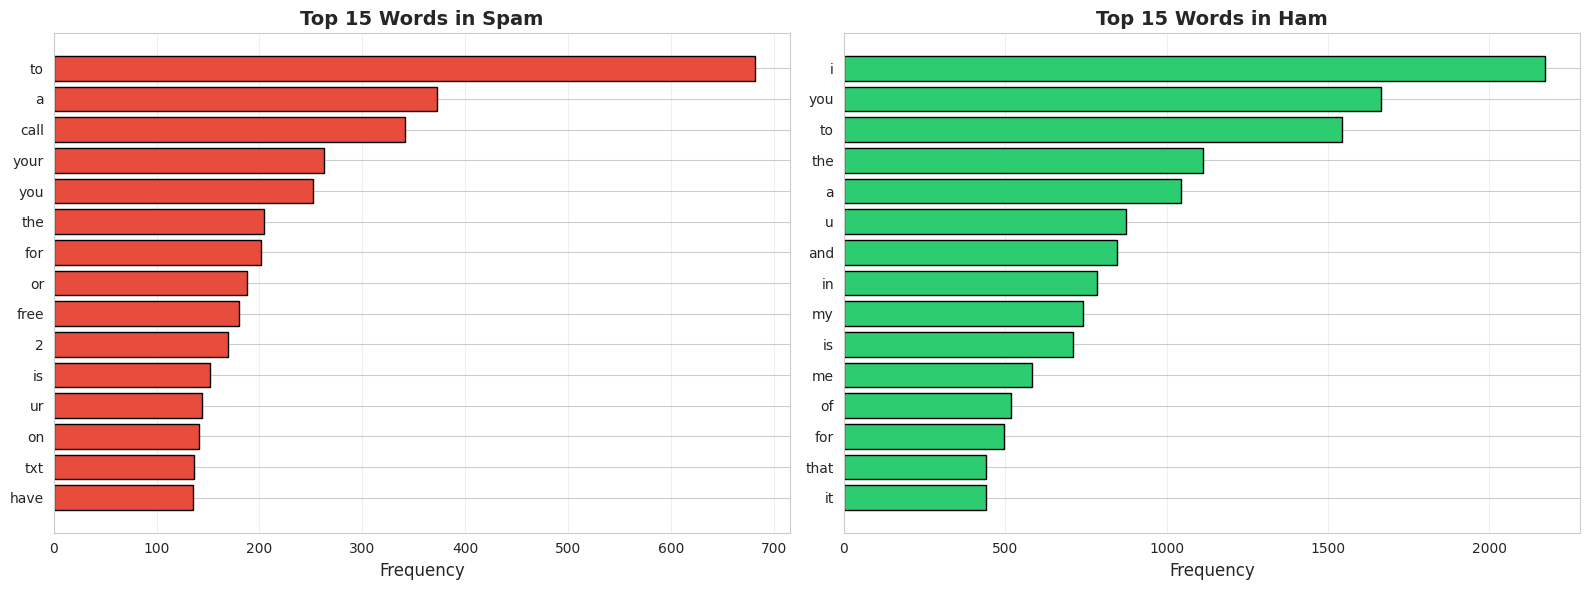

In [17]:
# Visualize top words comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spam words
spam_words, spam_counts = zip(*spam_freq[:15])
axes[0].barh(spam_words, spam_counts, color="#e74c3c", edgecolor="black")
axes[0].set_title("Top 15 Words in Spam", fontsize=14, weight="bold")
axes[0].set_xlabel("Frequency", fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

# Ham words
ham_words, ham_counts = zip(*ham_freq[:15])
axes[1].barh(ham_words, ham_counts, color="#2ecc71", edgecolor="black")
axes[1].set_title("Top 15 Words in Ham", fontsize=14, weight="bold")
axes[1].set_xlabel("Frequency", fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Print spam vs ham comparison
print("\n" + "=" * 60)
print("SPAM vs HAM - TOP WORDS COMPARISON")
print("=" * 60)
print(f"{'SPAM':<30} {'HAM'}")
print("-" * 60)
for (s_word, s_count), (h_word, h_count) in zip(
    spam_freq[:15], ham_freq[:15]
):
    s_text = f"{s_word} ({s_count:,})"
    padding = 30 - len(s_text)
    print(f"{s_text}{' ' * padding}{h_word} ({h_count:,})")


SPAM vs HAM - TOP WORDS COMPARISON
SPAM                           HAM
------------------------------------------------------------
to (682)                      i (2,172)
a (373)                       you (1,665)
call (342)                    to (1,544)
your (263)                    the (1,113)
you (252)                     a (1,046)
the (204)                     u (874)
for (201)                     and (845)
or (188)                      in (786)
free (180)                    my (741)
2 (169)                       is (710)
is (152)                      me (584)
ur (144)                      of (518)
on (141)                      for (496)
txt (136)                     that (442)
have (135)                    it (440)


## 7. Specific Patterns in Spam

Analyze spam-specific indicators such as promotional words, special
characters, URLs, and phone numbers.

In [19]:
# Define spam indicators
spam_indicators = [
    "free",
    "winner",
    "win",
    "prize",
    "cash",
    "call",
    "claim",
    "urgent",
    "txt",
    "text",
    "mobile",
    "£",
    "reward",
]

# Count occurrences
spam_indicator_counts = {}
for indicator in spam_indicators:
    spam_count = df[df["label"] == "spam"]["text"].str.lower().str.\
                 contains(indicator, regex=False).sum()
    ham_count = df[df["label"] == "ham"]["text"].str.lower().str.\
                contains(indicator, regex=False).sum()
    spam_indicator_counts[indicator] = {
        "spam": spam_count,
        "ham": ham_count,
    }

print("Spam indicators analyzed.")

Spam indicators analyzed.


In [20]:
# Print spam indicators table
print("=" * 60)
print("SPAM INDICATORS FREQUENCY")
print("=" * 60)
print(f"{'Indicator':<15} {'Spam Count':>12} {'Ham Count':>12} "
      f"{'Ratio':>10}")
print("-" * 60)

for indicator, counts in sorted(
    spam_indicator_counts.items(),
    key=lambda x: x[1]["spam"],
    reverse=True,
):
    ratio = (
        counts["spam"] / counts["ham"]
        if counts["ham"] > 0
        else float("inf")
    )
    ratio_str = f"{ratio:.1f}:1" if ratio != float("inf") else "∞:1"
    print(
        f"{indicator:<15} {counts['spam']:>12,} "
        f"{counts['ham']:>12,} {ratio_str:>10}"
    )

SPAM INDICATORS FREQUENCY
Indicator         Spam Count    Ham Count      Ratio
------------------------------------------------------------
call                     347          288      1.2:1
£                        253            4     63.2:1
free                     199           66      3.0:1
txt                      178           16     11.1:1
mobile                   147           15      9.8:1
text                     137           87      1.6:1
claim                    116            0        ∞:1
win                      100           66      1.5:1
prize                     89            0        ∞:1
cash                      68           13      5.2:1
urgent                    62            7      8.9:1
winner                    23            0        ∞:1
reward                    10            2      5.0:1


In [21]:
# Analyze special patterns
def count_pattern(text, pattern):
    """Count occurrences of regex pattern in text.

    Args:
        text: Input text string.
        pattern: Regex pattern to search for.

    Returns:
        Number of pattern occurrences.
    """
    return len(re.findall(pattern, text))


# URL pattern
df["has_url"] = df["text"].str.contains(
    r"http[s]?://|www\.", case=False, regex=True
)

# Phone number pattern (various formats)
df["has_phone"] = df["text"].str.contains(
    r"\b\d{5,}\b|\b\d{3}[-.]?\d{3}[-.]?\d{4}\b", regex=True
)

# Exclamation marks
df["exclamation_count"] = df["text"].apply(
    lambda x: count_pattern(x, r"!")
)

# Capital letters ratio
df["capital_ratio"] = df["text"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0
             else 0
)

print("Special patterns analyzed.")

Special patterns analyzed.


In [22]:
# Print pattern analysis
print("\n" + "=" * 60)
print("SPECIAL PATTERNS ANALYSIS")
print("=" * 60)

patterns = [
    ("has_url", "Contains URL"),
    ("has_phone", "Contains Phone Number"),
]

print(f"\n{'Pattern':<25} {'Spam %':>15} {'Ham %':>15}")
print("-" * 60)

for col, label in patterns:
    spam_pct = (
        df[df["label"] == "spam"][col].sum()
        / len(df[df["label"] == "spam"])
        * 100
    )
    ham_pct = (
        df[df["label"] == "ham"][col].sum()
        / len(df[df["label"] == "ham"])
        * 100
    )
    print(f"{label:<25} {spam_pct:>14.2f}% {ham_pct:>14.2f}%")

# Numeric patterns
print("\n" + "-" * 60)
print("\nNUMERIC PATTERN STATISTICS:")
print("-" * 60)
for metric in ["exclamation_count", "capital_ratio"]:
    print(f"\n{metric.replace('_', ' ').title()}:")
    for label in ["spam", "ham"]:
        data = df[df["label"] == label][metric]
        print(
            f"  {label.capitalize()}: "
            f"Mean={data.mean():.3f}, Median={data.median():.3f}"
        )


SPECIAL PATTERNS ANALYSIS

Pattern                            Spam %           Ham %
------------------------------------------------------------
Contains URL                       14.19%           0.04%
Contains Phone Number              75.37%           0.06%

------------------------------------------------------------

NUMERIC PATTERN STATISTICS:
------------------------------------------------------------

Exclamation Count:
  Spam: Mean=0.726, Median=0.000
  Ham: Mean=0.174, Median=0.000

Capital Ratio:
  Spam: Mean=0.111, Median=0.099
  Ham: Mean=0.060, Median=0.036


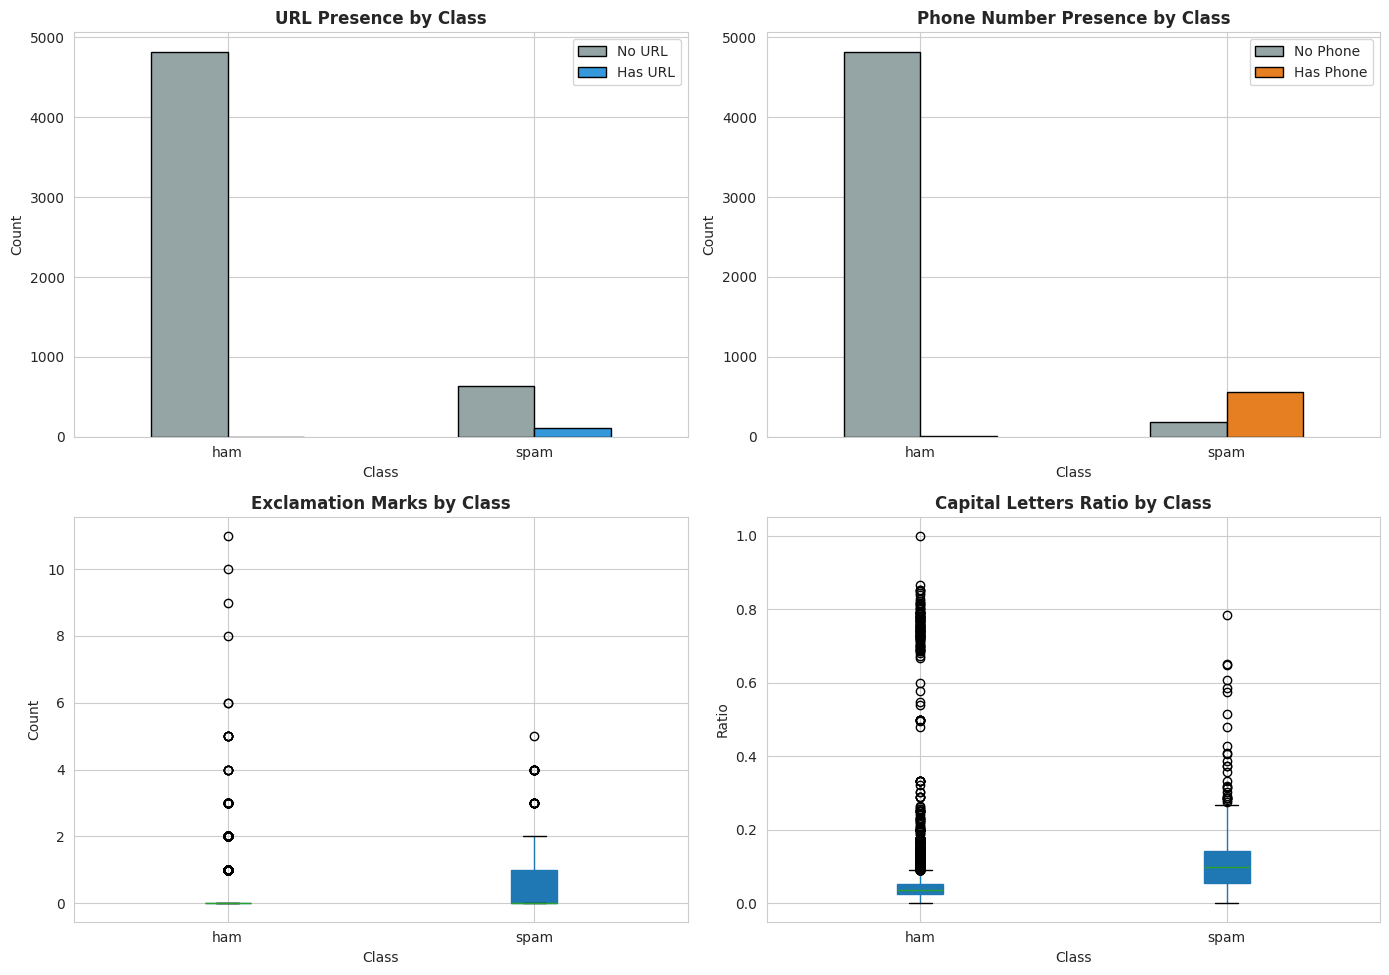

In [23]:
# Visualize pattern differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# URL presence
url_counts = df.groupby(["label", "has_url"]).size().unstack(
    fill_value=0
)
url_counts.plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#95a5a6", "#3498db"],
    edgecolor="black",
)
axes[0, 0].set_title("URL Presence by Class", fontsize=12, weight="bold")
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(["No URL", "Has URL"])
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# Phone number presence
phone_counts = df.groupby(["label", "has_phone"]).size().unstack(
    fill_value=0
)
phone_counts.plot(
    kind="bar",
    ax=axes[0, 1],
    color=["#95a5a6", "#e67e22"],
    edgecolor="black",
)
axes[0, 1].set_title(
    "Phone Number Presence by Class", fontsize=12, weight="bold"
)
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(["No Phone", "Has Phone"])
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Exclamation marks
df.boxplot(
    column="exclamation_count",
    by="label",
    ax=axes[1, 0],
    patch_artist=True,
)
axes[1, 0].set_title(
    "Exclamation Marks by Class", fontsize=12, weight="bold"
)
axes[1, 0].set_xlabel("Class")
axes[1, 0].set_ylabel("Count")

# Capital ratio
df.boxplot(
    column="capital_ratio", by="label", ax=axes[1, 1], patch_artist=True
)
axes[1, 1].set_title(
    "Capital Letters Ratio by Class", fontsize=12, weight="bold"
)
axes[1, 1].set_xlabel("Class")
axes[1, 1].set_ylabel("Ratio")

plt.suptitle("")
plt.tight_layout()
plt.show()

## 8. Key Findings Summary

### Main Observations

**Dataset Characteristics**:
- Total messages: 5,571
- Class distribution: ~13% spam, ~87% ham (imbalanced)
- No missing values
- Contains duplicates that should be handled

**Text Length Patterns**:
- Spam messages tend to be longer than ham messages
- Spam: Higher mean character count and word count
- Ham: More concise, conversational style

**Spam Indicators**:
- Common spam words: "call", "free", "text", "claim", "prize",
  "winner"
- Spam contains more phone numbers and URLs
- Higher use of exclamation marks and capital letters
- Promotional/commercial language patterns

**Ham Characteristics**:
- Informal, conversational language
- Personal pronouns ("i", "you", "u")
- Shorter messages
- Less aggressive punctuation

### Preprocessing Recommendations

Based on the EDA findings:

1. **Handle duplicates**: Remove or investigate duplicate messages

2. **Class imbalance**: Consider stratified sampling for train/val/test
   splits. Evaluate models using precision, recall, F1-score, not just
   accuracy.

3. **Text normalization**:
   - Convert to lowercase
   - Handle special characters and punctuation
   - Consider keeping or extracting URL/phone patterns as features

4. **Feature engineering**:
   - Text length features (char count, word count)
   - Special character ratios (capitals, exclamation marks)
   - Presence of spam indicators
   - URL and phone number flags

5. **Tokenization**: Standard word tokenization with vocabulary size
   based on dataset (likely 5000-10000 tokens)

6. **Stop words**: Be cautious removing stop words as some ("free",
   "call") are spam indicators

7. **Model evaluation**: Focus on precision for spam class to minimize
   false positives (legitimate messages marked as spam)

In [24]:
print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)
print(f"Dataset: {len(df):,} messages analyzed")
print(f"Classes: {df['label'].nunique()} (ham, spam)")
print(f"Features analyzed: {len(df.columns)}")
print("\nNext steps: Preprocessing and model development")
print("=" * 60)


EDA COMPLETED SUCCESSFULLY
Dataset: 5,572 messages analyzed
Classes: 2 (ham, spam)
Features analyzed: 8

Next steps: Preprocessing and model development
